# EPInformer — predict enhancer activity **and** gene expression

A single inference notebook (in the style of pinellolab/EPInformer's `predict_enhancer_activity.ipynb`
and `predict_gene_expression.ipynb`) for this reproduction, covering **both** models with our
trained checkpoints:

- **Part 1 — Enhancer-activity encoder** (`enhancer_predictor_256bp`): predict 256 bp activity from
  sequence, in-silico saturation mutagenesis (motif discovery), and 12-fold cross-chromosome evaluation.
- **Part 2 — Gene expression** (`EPInformer_v2`, shipped `f3` = 3 enhancer features + promoter signal,
  frozen encoder): predict K562 RNA & CAGE and evaluate 12-fold.

Run from the repo root on the HPC (conda env with `torch`, `h5py`, `kipoiseq`, `tangermeme`, `seaborn`).

In [1]:
%matplotlib inline
import os, sys, glob
import numpy as np, pandas as pd
import torch
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_style('white')
import kipoiseq
sys.path.insert(0, '.')
from EPInformer.models import EPInformer_v2, enhancer_predictor_256bp
from preprocessing.fasta import FastaStringExtractor

device = 'cuda' if torch.cuda.is_available() else 'cpu'
CELL = 'K562'
FASTA = 'data/reference/hg38/hg38.fa'
EXPR_CSV = 'data/GM12878_K562_18377_gene_expr_fromXpresso_with_sequence_strand.csv'
SPLIT_CSV = 'data/leave_chrom_out_crossvalidation_split_18377genes.csv'
print('device:', device)

def one_hot(seq):
    return kipoiseq.transforms.functional.one_hot_dna(seq, neutral_value=0.0).astype(np.float32)

device: cuda


## Part 1 — Enhancer activity + ISM at the KLF1 enhancer (faithful reproduction of pinellolab's `predict_enhancer_activity.ipynb`)

Predict K562 enhancer activity in 256-bp windows across the CRISPRi-validated **KLF1** enhancer, then
run in-silico saturation mutagenesis (ISM) to expose the TF motif — reproducing the upstream
EPInformer notebook **cell-for-cell** with the **published fold-8 encoder**, the **hg19** genome, and the
Fulco-2019 CRISPRi-FlowFISH table (`iloc[1]` → hg19 `chr19:12,978,355`, ≈ −20 kb from the KLF1 TSS).
The upstream `predict_enhancer_activity` returns **raw** activity (`2**pred - 0.1`) over 12 windows.
Only two lines differ from upstream: the `tangermeme.ism`→`tangermeme.saturation_mutagenesis` rename
and the local hg19 FASTA path. (A hg38 / log2 / multi-build view of the same encoder is in
`reproduce_github_enhancer_activity.ipynb`'s sibling notebook history.)

In [2]:
# Published pinellolab K562 encoder (fold 8) -- the exact checkpoint from predict_enhancer_activity.ipynb.
# This Part-1 section runs on CPU to match upstream exactly (encoder output is device-independent).
enc = enhancer_predictor_256bp()   # CPU
enc_ckpt = 'trained_models/pretrained_enhancer_encoder/fold_8_best_K562_seq2activityLog2_leaveChrOut_combinedRS_2bins_bs64_H3K27ac_adamW_erisxdl_r0_checkpoint.pt'
enc.load_state_dict(torch.load(enc_ckpt, map_location='cpu', weights_only=False)['model_state_dict'])
enc.eval()

# ISM: tangermeme.ism was renamed tangermeme.saturation_mutagenesis in >=1.x (identical function)
try:
    from tangermeme.ism import saturation_mutagenesis
except ModuleNotFoundError:
    from tangermeme.saturation_mutagenesis import saturation_mutagenesis
from tangermeme.plot import plot_logo

# upstream scripts/utils.py helpers, verbatim; only the hg19 path points at our local symlink
HG19_FASTA = 'data/reference/hg19/hg19.fa'

def one_hot_encode(sequence):
    return kipoiseq.transforms.functional.one_hot_dna(sequence).astype(np.float32)

def predict_enhancer_activity(enhancer_model, chrom, position, window_size=1024, stride=128,
                              device='cpu', fasta_path=HG19_FASTA):
    hg19_fasta_extractor = FastaStringExtractor(fasta_path)
    center = position
    print('The extened enhancer region: {}:{}-{}'.format(chrom, center - window_size, center + window_size))
    info_list = []
    for i in range(center - window_size, center + window_size, stride):
        seq = hg19_fasta_extractor.extract(kipoiseq.Interval(chrom, i, i + 256))
        seq_code = one_hot_encode(seq)[np.newaxis, np.newaxis, :]
        with torch.no_grad():
            pred = enhancer_model(torch.Tensor(seq_code).to(device)).cpu().detach().numpy()[0]
            pred_ori = 2 ** pred - 0.1
        info_list.append([chrom, i, i + 256, seq, center, pred_ori])
    return pd.DataFrame(info_list, columns=['chrom', 'start', 'end', 'seq', 'enhancer_mid', 'pred'])

In [3]:
# Fulco-2019 CRISPRi-FlowFISH (Nat Genet 41588_2019_538, Suppl Table 6a): CRISPRi-validated KLF1 enhancers
flowfish_df = pd.read_excel('data/CRISPRi-FlowFISH_Fulco2019/41588_2019_538_MOESM3_ESM.xlsx',
                            sheet_name='Supplementary Table 6a', skiprows=[0])
flowfish_df['mid'] = flowfish_df['start'] + (flowfish_df['end'] - flowfish_df['start']) / 2
flowfish_df['Distance_withDirect'] = flowfish_df['mid'] - flowfish_df['Gene TSS']
flowfish_df['Distance'] = np.abs(flowfish_df['Distance_withDirect'])
flowfish_100kb_df = flowfish_df[flowfish_df['Distance'] < 100_000]
KLF1_validated_enhancers = flowfish_100kb_df[(flowfish_100kb_df['Gene'] == 'KLF1') &
                                             (flowfish_100kb_df['Significant']) &
                                             (flowfish_100kb_df['Fraction change in gene expr'] < 0)].reset_index()

enhancer_locus = KLF1_validated_enhancers.iloc[1]['mid']
enhancer_chrom = KLF1_validated_enhancers.iloc[1]['chr']
pred_info = predict_enhancer_activity(enc, enhancer_chrom, int(enhancer_locus), window_size=512 + 256, stride=128, device='cpu')
KLF1_validated_enhancers[['chr', 'start', 'end', 'mid', 'Gene TSS', 'Distance_withDirect', 'Fraction change in gene expr']]

The extened enhancer region: chr19:12977587-12979123


,chr,start,end,mid,Gene TSS,Distance_withDirect,Fraction change in gene expr
0,chr19,12958325,12958825,12958575.0,12998017,-39442.0,-0.057784
1,chr19,12977965,12978745,12978355.0,12998017,-19662.0,-0.026087
2,chr19,12992085,12992645,12992365.0,12998017,-5652.0,-0.161863
3,chr19,12999705,13000205,12999955.0,12998017,1938.0,-0.169294
4,chr19,13001505,13002192,13001848.5,12998017,3831.5,-0.124012


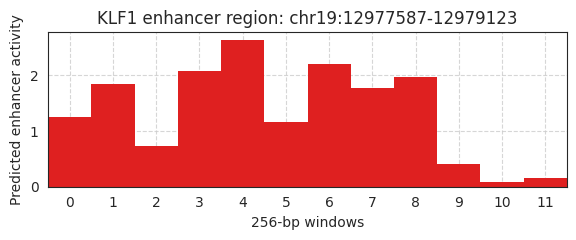

In [4]:
plt.figure(figsize=(6, 2.5))
sns.barplot(x=pred_info.index, y='pred', data=pred_info, color='red', width=1, linewidth=0)
plt.grid(linestyle='--', alpha=0.8)
plt.ylabel('Predicted enhancer activity')
plt.xlabel('256-bp windows')
plt.title('KLF1 enhancer region: chr19:12977587-12979123')
plt.tight_layout(); plt.show()

### In-silico saturation mutagenesis (motif discovery)
Mutate every base of the top-activity 256-bp window and plot the effect with `plot_logo` — TF motifs
appear as tall letters (GATA + ETS/GGAA at this KLF1 enhancer).

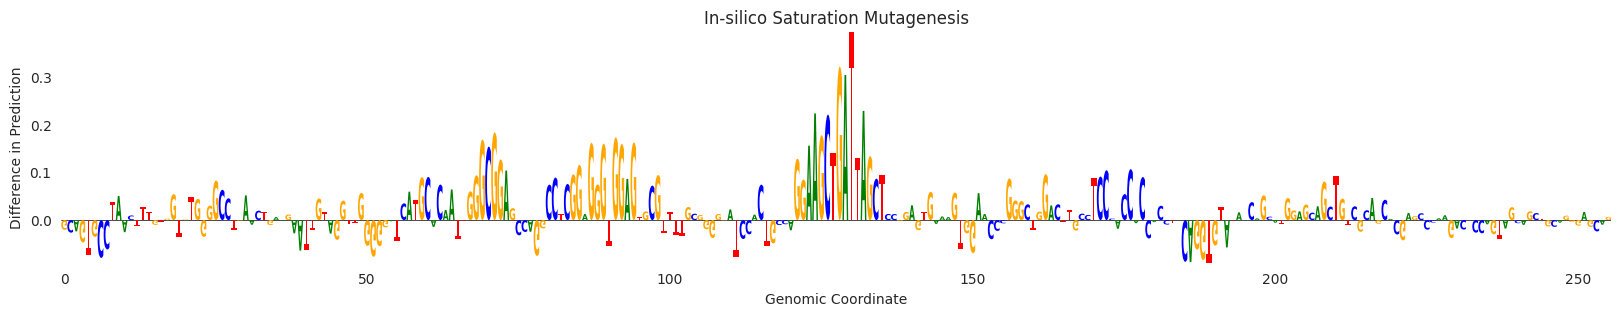

In [5]:
# calculate ISM score for the top 256-bp window
top_activity_256bp = pred_info.sort_values(by='pred', ascending=False).iloc[0]
seq_ohe = one_hot_encode(top_activity_256bp.seq)
seq_tensor = torch.from_numpy(seq_ohe).unsqueeze(0).permute(0, 2, 1)
seq_ISM = saturation_mutagenesis(enc, seq_tensor, device='cpu')

plt.figure(figsize=(20, 3))
ax = plt.subplot(111)
plot_logo(seq_ISM[0], ax=ax)
plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction")
plt.title("In-silico Saturation Mutagenesis")
plt.show()

### 12-fold cross-chromosome evaluation (K562 encoder) - our reproduction
Pool the held-out predictions from all 12 folds of **our** reproduced K562 encoder and plot
predicted vs. observed log2 activity. (The KLF1 demo above uses the published pinellolab
checkpoint; our reproduction below reaches pooled R ~0.74 and agrees with it, profile corr ~0.94.)

K562 encoder — pooled 12-fold Pearson R = 0.7382  (n=273,125)


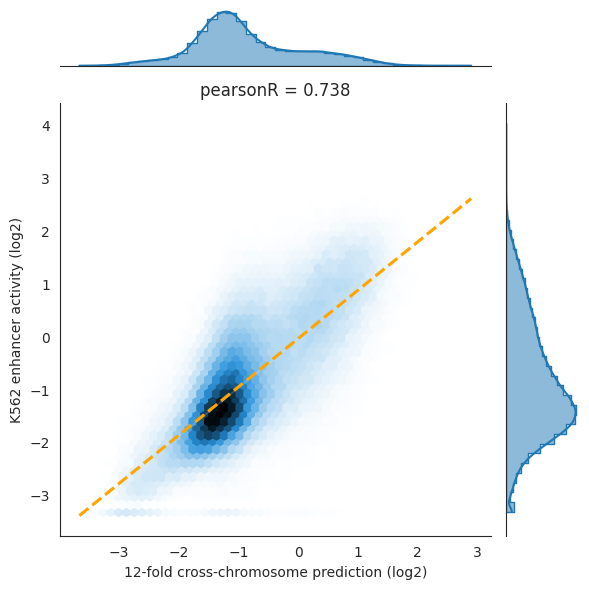

In [6]:
enc_dfs = []
for f in sorted(glob.glob('results/seqencoder/K562_repro/predictions/fold_*_predictions.csv')):
    if 'summit_only' in f:
        continue
    d = pd.read_csv(f); pc = 'preds' if 'preds' in d.columns else 'Pred'
    enc_dfs.append(pd.DataFrame({'Pred': d[pc], 'actual': d['actual']}))
enc_all = pd.concat(enc_dfs, ignore_index=True)
rE, _ = stats.pearsonr(enc_all['Pred'], enc_all['actual'])
print(f'K562 encoder — pooled 12-fold Pearson R = {rE:.4f}  (n={len(enc_all):,})')

ax = sns.jointplot(data=enc_all, x='Pred', y='actual', kind='hex',
                   marginal_kws={'bins': 40, 'element': 'step', 'kde': True})
ax.plot_joint(sns.regplot, color='r', scatter=False, line_kws={'color': 'orange', 'linestyle': 'dashed'})
plt.title(f'pearsonR = {rE:.3f}')
ax.set_axis_labels('12-fold cross-chromosome prediction (log2)', 'K562 enhancer activity (log2)')
plt.tight_layout(); plt.show()

## Part 2 — Gene expression (`EPInformer_v2`, shipped f3)

Predict K562 **RNA** and **CAGE** with the frozen-encoder f3 model (3 enhancer features + promoter
signal), running true 12-fold cross-chromosome inference from our per-fold checkpoints.
The gene HDF5 preloads all promoter/enhancer sequences (~36 GB RAM), so run this on an HPC node.

In [7]:
from torch.utils.data import Subset, DataLoader
from train_EPInformer import promoter_enhancer_dataset

split_df = pd.read_csv(SPLIT_CSV, index_col=0)
gl = pd.read_csv(f'batch_output/{CELL}/links/GeneList.txt', sep='\t', index_col='name')
gl['promoter_activity'] = np.sqrt(gl['DHS.RPM.TSS1Kb'] * gl['H3K27ac.RPM.TSS1Kb'])
MODEL_NAME = 'EPInformerV2.preTrainedConv.{cell}.{et}.60enhs.3feats.rnafeats.prmsig.nonrmprmseq.100kb2TSS'

def predict_subset(model, ds_sub, device, batch_size=16):
    dl = DataLoader(ds_sub, batch_size=batch_size, num_workers=2)
    preds, actual, eids = [], [], []
    model.eval()
    with torch.no_grad():
        for pe, rna, ef, y, act, eid in dl:
            pe, rna, ef = pe.float().to(device), rna.float().to(device), ef.float().to(device)
            model._enh_activity = act.to(device)
            out, _ = model(pe, enh_feats=ef, rna_feats=rna)
            preds += list(out.flatten().cpu().numpy()); actual += list(np.asarray(y)); eids += list(eid)
    return pd.DataFrame({'Pred': preds, 'actual': actual}, index=eids)

prediction_res = []
for et in ['RNA', 'CAGE']:
    ckdir = f'EPInformer_models/{CELL}_repro_{et}_prm'
    mn = MODEL_NAME.format(cell=CELL, et=et)
    ds = promoter_enhancer_dataset(h5_path=f'batch_output/{CELL}/encoding/{CELL}_samples.h5',
            expr_csv=EXPR_CSV, cell_type=CELL, expr_type=et, n_enh_feats=3, distance_thr=100_000,
            max_n_enh=60, use_prm_signal=True, rm_prm_seq=False, promoter_activity_df=gl, strand_aware=False)
    ensid_df = pd.DataFrame({'idx': np.arange(len(ds._ensid))}, index=list(ds._ensid))
    for fi in range(1, 13):
        test_ensid = split_df[split_df[f'fold_{fi}'] == 'test'].index
        test_idx = ensid_df.loc[ensid_df.index.intersection(test_ensid)]['idx'].values
        model = EPInformer_v2(n_encoder=3, n_enhancer=60, out_dim=64, n_extraFeat=3, useBN=False,
                              usePromoterSignal=True, useFeat=True, device=device).to(device)
        ck = torch.load(f'{ckdir}/fold_{fi}_best_{mn}_checkpoint.pt', map_location=device, weights_only=False)
        model.load_state_dict(ck['model_state_dict'])
        df = predict_subset(model, Subset(ds, test_idx), device)
        df['fold'] = fi; df['expr_type'] = et
        prediction_res.append(df)
    del ds
prediction_res = pd.concat(prediction_res)
for et in ['RNA', 'CAGE']:
    sub = prediction_res[prediction_res['expr_type'] == et]
    print(f'K562 {et}: pooled 12-fold Pearson R = {stats.pearsonr(sub.Pred, sub.actual)[0]:.4f}')

Loading HDF5 data into shared memory...


  Expression column: Actual_K562 (fallback)


Pre-computing pe_ohe and pe_feats for all genes...


Loaded: 18377 genes, pe_ohe: 35.9 GB


Loading HDF5 data into shared memory...


  Expression column: Actual_K562 (fallback)


Pre-computing pe_ohe and pe_feats for all genes...


Loaded: 18377 genes, pe_ohe: 35.9 GB


K562 RNA: pooled 12-fold Pearson R = 0.8564
K562 CAGE: pooled 12-fold Pearson R = 0.8673


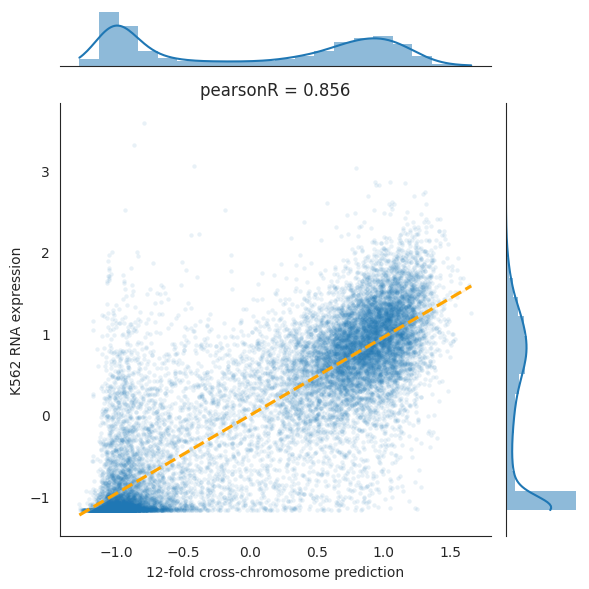

In [8]:
# K562 RNA — predicted vs observed (12-fold pooled)
sub = prediction_res[prediction_res['expr_type'] == 'RNA'].reset_index(drop=True)
rG, _ = stats.pearsonr(sub['Pred'], sub['actual'])
ax = sns.jointplot(data=sub, x='Pred', y='actual', kind='scatter',
                   joint_kws={'marker': 'o', 's': 10, 'alpha': 0.1, 'linewidth': 0},
                   marginal_kws={'bins': 20, 'element': 'step', 'kde': True, 'linewidth': 0})
ax.plot_joint(sns.regplot, color='r', scatter=False, line_kws={'color': 'orange', 'linestyle': 'dashed'})
plt.title(f'pearsonR = {rG:.3f}')
ax.set_axis_labels('12-fold cross-chromosome prediction', 'K562 RNA expression')
plt.tight_layout(); plt.show()

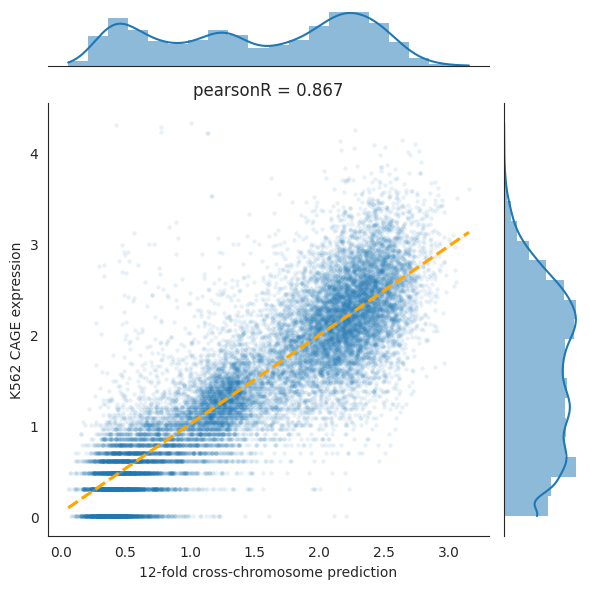

In [9]:
# K562 CAGE — predicted vs observed (12-fold pooled)
sub = prediction_res[prediction_res['expr_type'] == 'CAGE'].reset_index(drop=True)
rG, _ = stats.pearsonr(sub['Pred'], sub['actual'])
ax = sns.jointplot(data=sub, x='Pred', y='actual', kind='scatter',
                   joint_kws={'marker': 'o', 's': 10, 'alpha': 0.1, 'linewidth': 0},
                   marginal_kws={'bins': 20, 'element': 'step', 'kde': True, 'linewidth': 0})
ax.plot_joint(sns.regplot, color='r', scatter=False, line_kws={'color': 'orange', 'linestyle': 'dashed'})
plt.title(f'pearsonR = {rG:.3f}')
ax.set_axis_labels('12-fold cross-chromosome prediction', 'K562 CAGE expression')
plt.tight_layout(); plt.show()

### Expression across all reproduced cell lines (RNA)
Pooled 12-fold R for the shipped f3 model (from the saved per-fold predictions).

In [10]:
EXPR_DIR = {'K562': 'K562_repro_RNA_prm', 'GM12878': 'GM12878_repro_RNA_consistentBAM_prm',
            'HepG2': 'HepG2_repro_RNA', 'HUVEC': 'HUVEC_repro_RNA',
            'NHEK': 'NHEK_repro_RNA', 'H1': 'H1_repro_RNA'}
rows = []
for c, d in EXPR_DIR.items():
    fs = sorted(glob.glob(f'EPInformer_models/{d}/fold_*_predictions.csv'))
    if not fs:
        continue
    df = pd.concat([pd.read_csv(f) for f in fs], ignore_index=True)
    pc = 'Pred' if 'Pred' in df.columns else 'pred'
    r, _ = stats.pearsonr(df[pc], df['actual'])
    rows.append({'cell': c, 'RNA_pearsonR': round(r, 4), 'n_genes': len(df) // 12})
pd.DataFrame(rows)

,cell,RNA_pearsonR,n_genes
0,K562,0.8564,1531
1,GM12878,0.8602,1531
2,HepG2,0.8447,1531
3,HUVEC,0.8390,1531
4,NHEK,0.8281,1531
5,H1,0.7811,1531
